In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#reading of Data
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
missing_count=df.isnull().sum()

missing_count

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#percentage of missing data

Percentage=df.isnull().sum()/df.shape[0]

Percentage

,0
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


In [ ]:
print("Missing value analysis:")

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percentage': Percentage.values
})

print(missing_df.to_string(index=False))

total_missing = missing_count.sum()
print("TOTAL MISSING VALUES:",total_missing)

if total_missing == 0:
    print("NO MISSING VALUES FOUND")
    print("   There is no missing values in this dataset")
else:
    print("MISSING VALUES DETECTED",total_missing)
    print("   Data cleaning required for missing values.")

Missing value analysis:
  Column  Missing_Count  Missing_Percentage
     age              0                 0.0
     sex              0                 0.0
     bmi              0                 0.0
children              0                 0.0
  smoker              0                 0.0
  region              0                 0.0
 charges              0                 0.0
TOTAL MISSING VALUES: 0
NO MISSING VALUES FOUND
   There is no missing values in this dataset


In [ ]:
#identifying inconsistent values

print("ANALYZING 'sex' COLUMN:")

print("   Unique values:",df['sex'].unique())

print("   Value counts:")

print(df['sex'].value_counts())

ANALYZING 'sex' COLUMN:
   Unique values: ['female' 'male']
   Value counts:
sex
male      676
female    662
Name: count, dtype: int64


In [ ]:
#identifying inconsistent values

print("ANALYZING 'smoker' COLUMN:")

print("   Unique values:",df['smoker'].unique())

print("   Value counts:")

print(df['smoker'].value_counts())

ANALYZING 'smoker' COLUMN:
   Unique values: ['yes' 'no']
   Value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64


In [ ]:
# Check for unexpected values

expected_smoker = ['yes', 'no']

unexpected_smoker = df[~df['smoker'].isin(expected_smoker)]

if len(unexpected_smoker) == 0:
    print("No inconsistent values found")
else:
    print("Inconsistent values found:", unexpected_smoker['smoker'].unique())
    print("Count:", len(unexpected_smoker))

No inconsistent values found


In [ ]:
#identifying inconsistent values

print("ANALYZING 'region' COLUMN:")

print("   Unique values:",df['region'].unique())

print("   Value counts:")

print(df['region'].value_counts())

ANALYZING 'region' COLUMN:
   Unique values: ['southwest' 'southeast' 'northwest' 'northeast']
   Value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [ ]:
# Check for unexpected values

expected_region = ['southeast', 'southwest','northeast','northwest']

unexpected_region = df[~df['region'].isin(expected_region)]

if len(unexpected_region) == 0:
    print("No inconsistent values found")
else:
    print("Inconsistent values found:", unexpected_region['region'].unique())
    print("Count:", len(unexpected_region))

No inconsistent values found


outliers remover not required


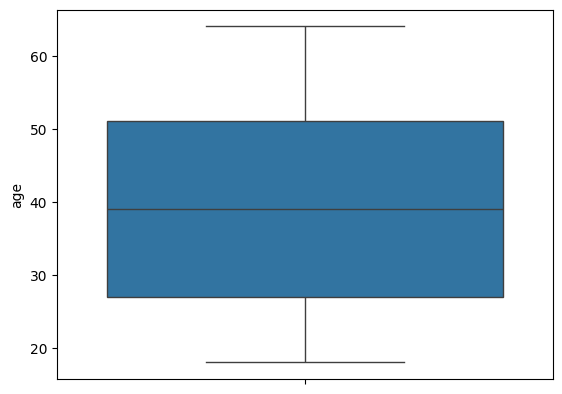

In [ ]:
#to detect whether outliers exist or not

sns.boxplot(df["age"])

#to detect outliers using iqr

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]
if len(outliers)==0:
    print("outliers remover not required")
else:
    print("outliers remover required as there are", outliers['age'],"outliers")

outliers remover required as there are 116     49.06
286     48.07
401     47.52
543     47.41
847     50.38
860     47.60
1047    52.58
1088    47.74
1317    53.13
Name: bmi, dtype: float64 outliers


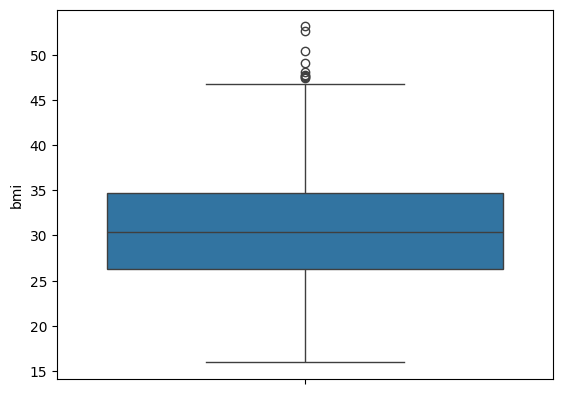

In [ ]:
#to detect whether outliers exist or not

sns.boxplot(df["bmi"])


#to detect outliers using iqr

Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]

if len(outliers)==0:
    print("outliers remover not required")
else:
    print("outliers remover required as there are", outliers['bmi'],"outliers")

In [ ]:
# Remove outliers from bmi column

df = df[(df['bmi'] >= lower) & (df['bmi'] <= upper)]

df.reset_index(drop=True, inplace=True)

print("Outliers removed successfully")
print("New shape of dataset:", df.shape)

Outliers removed successfully
New shape of dataset: (1183, 7)


outliers remover not required


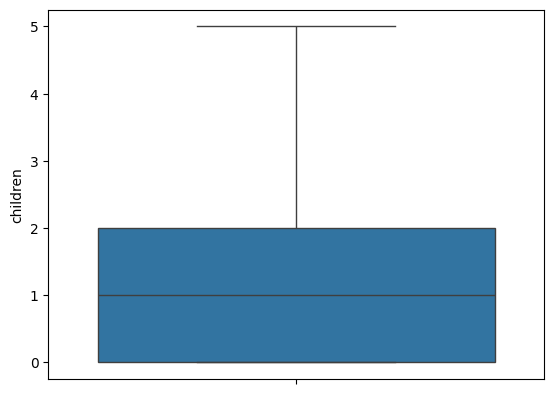

In [ ]:
#to detect whether outliers exist or not

sns.boxplot(df["children"])


#to detect outliers using iqr

Q1 = df['children'].quantile(0.25)
Q3 = df['children'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['children'] < lower) | (df['children'] > upper)]

if len(outliers)==0:
    print("outliers remover not required")
else:
    print("outliers remover required as there are", outliers['children'],"outliers")

outliers remover required as there are 14      39611.75770
19      36837.46700
23      37701.87680
29      38711.00000
30      35585.57600
           ...     
1300    62592.87309
1301    46718.16325
1303    37829.72420
1313    36397.57600
1323    43896.37630
Name: charges, Length: 138, dtype: float64 outliers


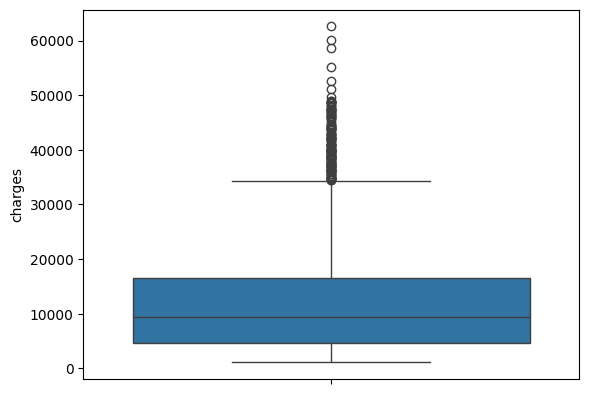

In [ ]:
#to detect whether outliers exist or not

sns.boxplot(df["charges"])


#to detect outliers using iqr

Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]

if len(outliers)==0:
    print("outliers remover not required")
else:
    print("outliers remover required as there are", outliers['charges'],"outliers")

In [ ]:
# Remove outliers from bmi column

df = df[(df['charges'] >= lower) & (df['charges'] <= upper)]

print("Outliers removed successfully")
print("New shape of dataset:", df.shape)

Outliers removed successfully
New shape of dataset: (0, 7)


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1


In [ ]:
df.drop_duplicates(inplace=True)
print("Duplicates removed")

Duplicates removed


In [ ]:
# to reconfirm if the categorical columns still have any inconsistent value

print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


<Axes: xlabel='bmi'>

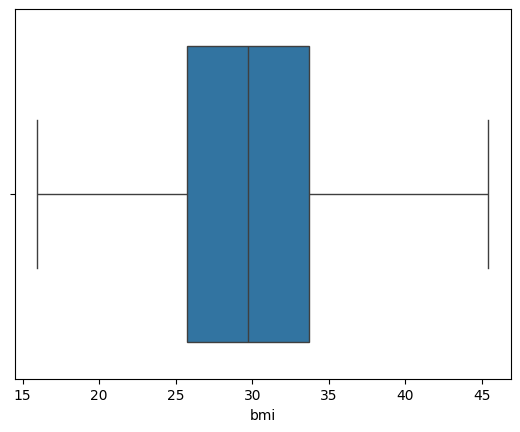

In [ ]:

sns.boxplot(x=df["bmi"])

In [ ]:
df.to_csv("cleaned_insurance.csv", index=False)